In [1]:
import os
import json
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

def read_json(path):
    with open(path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    return data

def write_json(data, path):
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    with open(path, 'w', encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)

In [2]:


def forgetting_rate(accuracy_matrix):
    """
    Computes forgetting for each task.
    
    Parameters:
    - accuracy_matrix: 2D numpy array of shape (num_tasks, num_tasks)
      Each row i represents accuracy on task i after training on tasks j=0..T-1
    
    Returns:
    - forgetting: list of forgetting values for each task
    - avg_forgetting: average forgetting across tasks (excluding the last task)
    """
    num_tasks = accuracy_matrix.shape[0]
    forgetting = []

    for i in range(num_tasks - 1):
        max_acc = np.max(accuracy_matrix[i, :i+1])  # Max accuracy before final training
        final_acc = accuracy_matrix[i, -1]          # Accuracy after training on all tasks
        forgetting.append(max_acc - final_acc)

    avg_forgetting = np.mean(forgetting)
    return forgetting, avg_forgetting


In [3]:
def make_matrices(accuracy_matrix):
    """
    Prepares the accuracy matrix for forgetting rate computation.
    
    Parameters:
    - accuracy_matrix: 2D numpy array of shape (num_tasks, num_tasks)
      Each row i represents accuracy on task i after training on tasks j=0..T-1
    
    Returns:
    - prepared_matrix: 2D numpy array of shape (num_tasks, num_tasks)
      The prepared matrix for forgetting rate computation
    """
    # Pivot the accuracy matrix
    prepared_matrix = accuracy_matrix.pivot(index='base_task', columns='task', values='accuracy').fillna(0).values
    return prepared_matrix.T


In [4]:
# Forgetting rate for baseline models
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/results-finance/finance/results/llm_forget_baseline/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))
write_json(forgetting_rates, f"/Users/sefika/phd_projects/llm-catastrophic-re/results-finance/finance/results/llm_forget_baseline/forgetting_rates.json")

Run 1 - Forgetting: [0.027522935779817015, 0.056872037914691975, 0.03418803418803407, 0.0]
Run 1 - Average Forgetting: 0.029645751970635764
Run 2 - Forgetting: [0.009174311926605005, 0.014218009478673022, -0.00854700854700896, 0.013636363636364002]
Run 2 - Average Forgetting: 0.007120419123658267
Run 3 - Forgetting: [0.003058103975534965, 0.023696682464455, 0.034188034188033956, -0.009090909090909038]
Run 3 - Average Forgetting: 0.01296297788427872
Run 4 - Forgetting: [0.03669724770642202, 0.08530805687203802, 0.017094017094017033, -0.009090909090909038]
Run 4 - Average Forgetting: 0.03250210314539201
Run 5 - Forgetting: [0.03058103975535098, -0.004739336492890933, 0.1965811965811971, 0.013636363636364002]
Run 5 - Average Forgetting: 0.05901481587000529
Average Forgetting across runs: 0.02824921359879401
Std Average Rates across runs: 0.01814747712670937


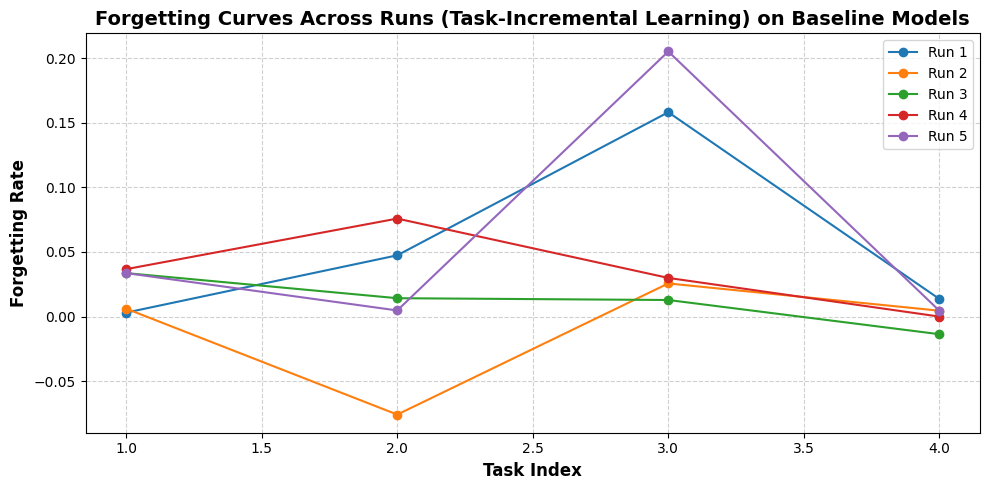

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on Baseline Models", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("finance_baseline_forgetting_curves.pdf", dpi=300)
plt.show()


In [14]:
# Forgetting rate for EWC
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/results-finance/finance/results/llm_forget_ewc/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))
write_json(forgetting_rates, f"/Users/sefika/phd_projects/llm-catastrophic-re/results-finance/finance/results/llm_forget_ewc/forgetting_rates.json")

Run 1 - Forgetting: [0.01834862385321101, 0.028436018957345932, 0.10683760683760601, -0.004545454545455074]
Run 1 - Average Forgetting: 0.03726919877567697
Run 2 - Forgetting: [0.006116207951070041, -0.023696682464455, -0.012820512820512997, 0.0]
Run 2 - Average Forgetting: -0.007600246833474489
Run 3 - Forgetting: [0.01223241590213997, 0.03791469194312802, 0.025641025641025994, 0.03181818181818097]
Run 3 - Average Forgetting: 0.02690157882611874
Run 4 - Forgetting: [0.03669724770642202, 0.07582938388625604, 0.02991452991453003, 0.0]
Run 4 - Average Forgetting: 0.03561029037680202
Run 5 - Forgetting: [0.033639143730886945, 0.004739336492890933, 0.20512820512820507, 0.004545454545454963]
Run 5 - Average Forgetting: 0.06201303497435948
Average Forgetting across runs: 0.030838771223896545
Std Average Rates across runs: 0.02249005160999273


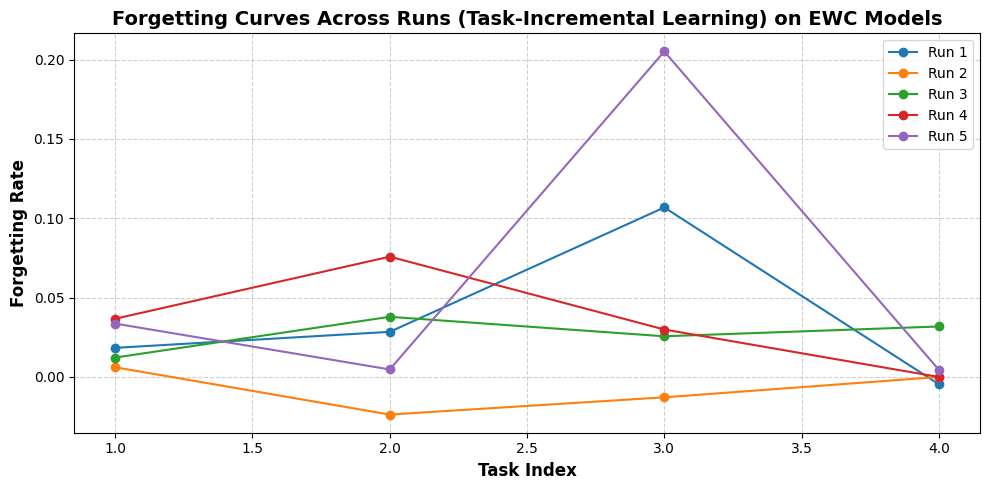

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on EWC Models", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("finance_ewc_forgetting_curves.pdf", dpi=300)
plt.show()


In [16]:
# Forgetting rate for MAS
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/results-finance/finance/results/llm_forget_mas/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))
write_json(forgetting_rates, f"/Users/sefika/phd_projects/llm-catastrophic-re/results-finance/finance/results/llm_forget_mas/forgetting_rates.json")

Run 1 - Forgetting: [0.003058103975535964, 0.04739336492891, 0.158119658119658, 0.013636363636363003]
Run 1 - Average Forgetting: 0.05555187266511674
Run 2 - Forgetting: [0.00611620795106993, -0.07582938388625593, 0.025641025641025994, 0.004545454545455074]
Run 2 - Average Forgetting: -0.009881673937176233
Run 3 - Forgetting: [0.033639143730886945, 0.014218009478673022, 0.012820512820511998, -0.013636363636364002]
Run 3 - Average Forgetting: 0.01176032559842699
Run 4 - Forgetting: [0.03669724770642202, 0.07582938388625604, 0.02991452991453003, 0.0]
Run 4 - Average Forgetting: 0.03561029037680202
Run 5 - Forgetting: [0.033639143730886945, 0.004739336492890933, 0.20512820512820507, 0.004545454545454963]
Run 5 - Average Forgetting: 0.06201303497435948
Average Forgetting across runs: 0.0310107699355058
Std Average Rates across runs: 0.026934488382258044


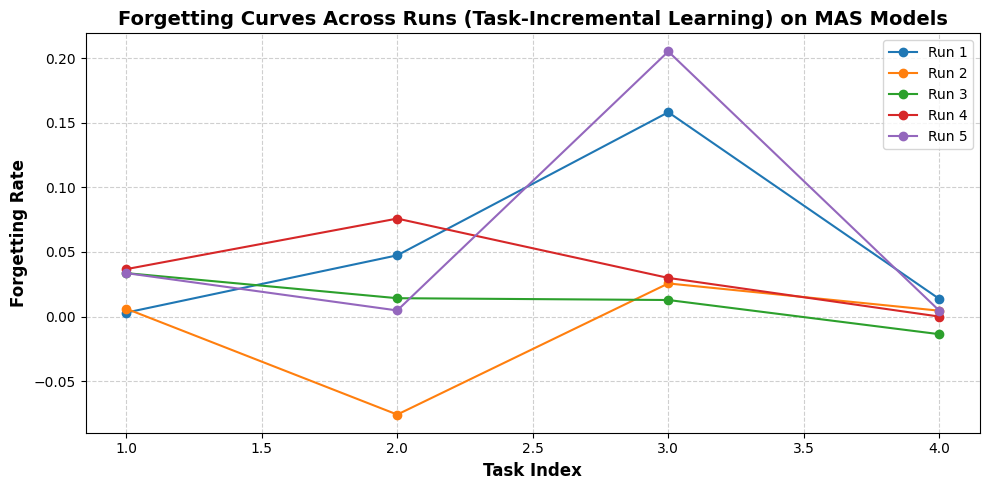

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on MAS Models", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("finance_mas_forgetting_curves.pdf", dpi=300)
plt.show()


In [9]:
# Forgetting rate for SI
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/results-finance/finance/results/si_finance_flan_random/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))
write_json(forgetting_rates, f"/Users/sefika/phd_projects/llm-catastrophic-re/results-finance/finance/results/si_finance_flan_random/forgetting_rates.json")

Run 1 - Forgetting: [0.009174311926605005, 0.014218009478673022, 0.06837606837606802, -0.004545454545455074]
Run 1 - Average Forgetting: 0.021805733808972744
Run 2 - Forgetting: [0.015290519877676045, -0.004739336492891044, 0.13675213675213704, 0.02272727272727293]
Run 2 - Average Forgetting: 0.04250764821604874
Run 3 - Forgetting: [0.015290519877675934, 0.028436018957346043, 0.025641025641025994, 0.013636363636364002]
Run 3 - Average Forgetting: 0.020750982028102993
Run 4 - Forgetting: [0.03669724770642202, 0.08530805687203802, 0.017094017094017033, -0.009090909090909038]
Run 4 - Average Forgetting: 0.03250210314539201
Run 5 - Forgetting: [0.03058103975535098, -0.004739336492890933, 0.1965811965811971, 0.013636363636364002]
Run 5 - Average Forgetting: 0.05901481587000529
Average Forgetting across runs: 0.035316256613704355
Std Average Rates across runs: 0.014254393946829366


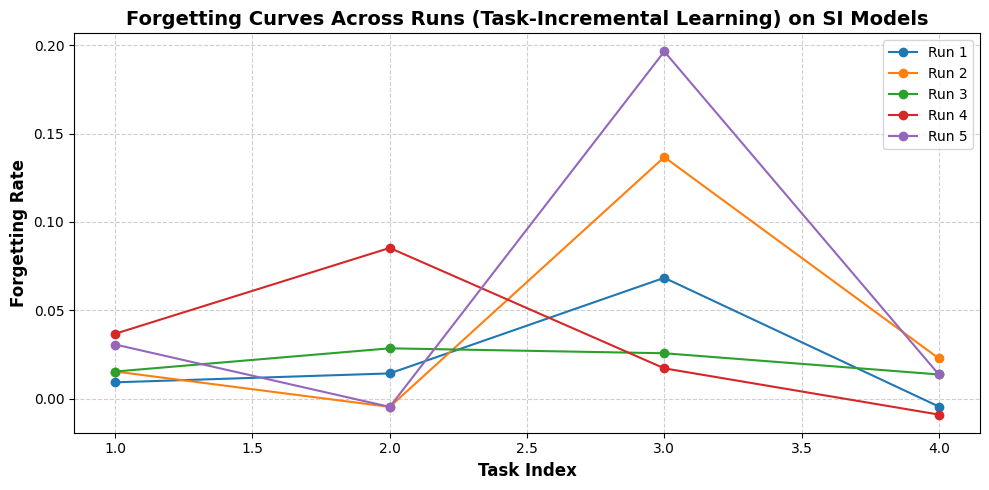

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on SI Models", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("finance_si_forgetting_curves.pdf", dpi=300)
plt.show()
